In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

c:\Users\paink\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/telco-customer-churn.csv")

In [3]:
df.head(5)

,age,annualincome,calldroprate,callfailurerate,callingnum,customerid,customersuspended,education,gender,homeowner,...,totalminsusedinlastmonth,unpaidbalance,usesinternetservice,usesvoiceservice,percentagecalloutsidenetwork,totalcallduration,avgcallduration,churn,year,month
0,12,168147,0.06,0.00,4251078442,1,Yes,Bachelor or equivalent,Male,Yes,...,15,19,No,No,0.82,5971,663,0,2015,1
1,12,168147,0.06,0.00,4251078442,1,Yes,Bachelor or equivalent,Male,Yes,...,15,19,No,No,0.82,3981,995,0,2015,2
2,42,29047,0.05,0.01,4251043419,2,Yes,Bachelor or equivalent,Female,Yes,...,212,34,No,Yes,0.27,7379,737,0,2015,1
3,42,29047,0.05,0.01,4251043419,2,Yes,Bachelor or equivalent,Female,Yes,...,212,34,No,Yes,0.27,1729,432,0,2015,2
4,58,27076,0.07,0.02,4251055773,3,Yes,Master or equivalent,Female,Yes,...,216,144,No,No,0.48,3122,624,0,2015,1


In [4]:
df.describe()

,age,annualincome,calldroprate,callfailurerate,callingnum,customerid,monthlybilledamount,numberofcomplaints,numberofmonthunpaid,numdayscontractequipmentplanexpiring,penaltytoswitch,totalminsusedinlastmonth,unpaidbalance,percentagecalloutsidenetwork,totalcallduration,avgcallduration,churn,year,month
count,20468.000000,20468.000000,20468.000000,20468.000000,2.046800e+04,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.0,20468.000000
mean,45.334327,124446.818253,0.035021,0.015239,4.220203e+09,4757.953342,59.630252,1.499169,3.489252,49.366816,248.792603,249.740522,126.656879,0.496528,3521.696306,721.521057,0.091020,2015.0,1.611687
std,19.624577,72129.392001,0.022996,0.011213,3.365196e+08,2751.070062,34.652681,1.119153,2.289740,28.874138,144.247247,144.198066,70.367800,0.288220,1959.642260,225.677596,0.287645,0.0,0.621895
min,12.000000,4.000000,0.000000,0.000000,1.022955e+08,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.0,1.000000
25%,28.000000,61898.000000,0.010000,0.010000,4.251031e+09,2372.750000,29.000000,0.000000,1.000000,24.000000,124.000000,126.000000,66.000000,0.250000,2047.750000,582.000000,0.000000,2015.0,1.000000
50%,45.000000,123689.500000,0.040000,0.020000,4.251054e+09,4754.000000,60.000000,2.000000,3.000000,49.000000,249.000000,249.000000,122.000000,0.500000,3365.000000,721.000000,0.000000,2015.0,2.000000
75%,62.000000,187065.250000,0.060000,0.030000,4.251077e+09,7141.250000,90.000000,3.000000,5.000000,74.000000,373.000000,374.000000,191.000000,0.750000,4786.250000,862.000000,0.000000,2015.0,2.000000
max,79.000000,249987.000000,0.070000,0.030000,4.251100e+09,9525.000000,119.000000,3.000000,7.000000,99.000000,499.000000,499.000000,249.000000,0.990000,16662.000000,1439.000000,1.000000,2015.0,3.000000


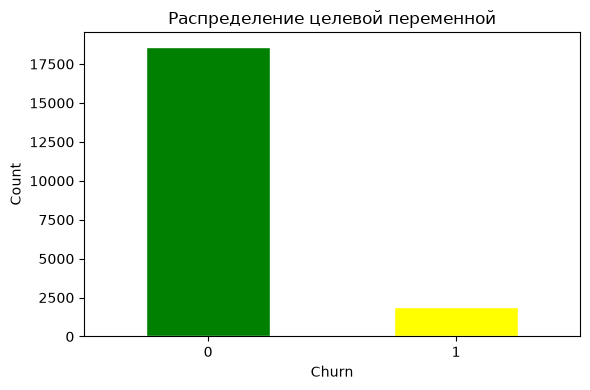

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4))
df['churn'].value_counts().plot(kind="bar", ax=ax, color=["green", "yellow"], edgecolor="white")
ax.set_title("Распределение целевой переменной")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

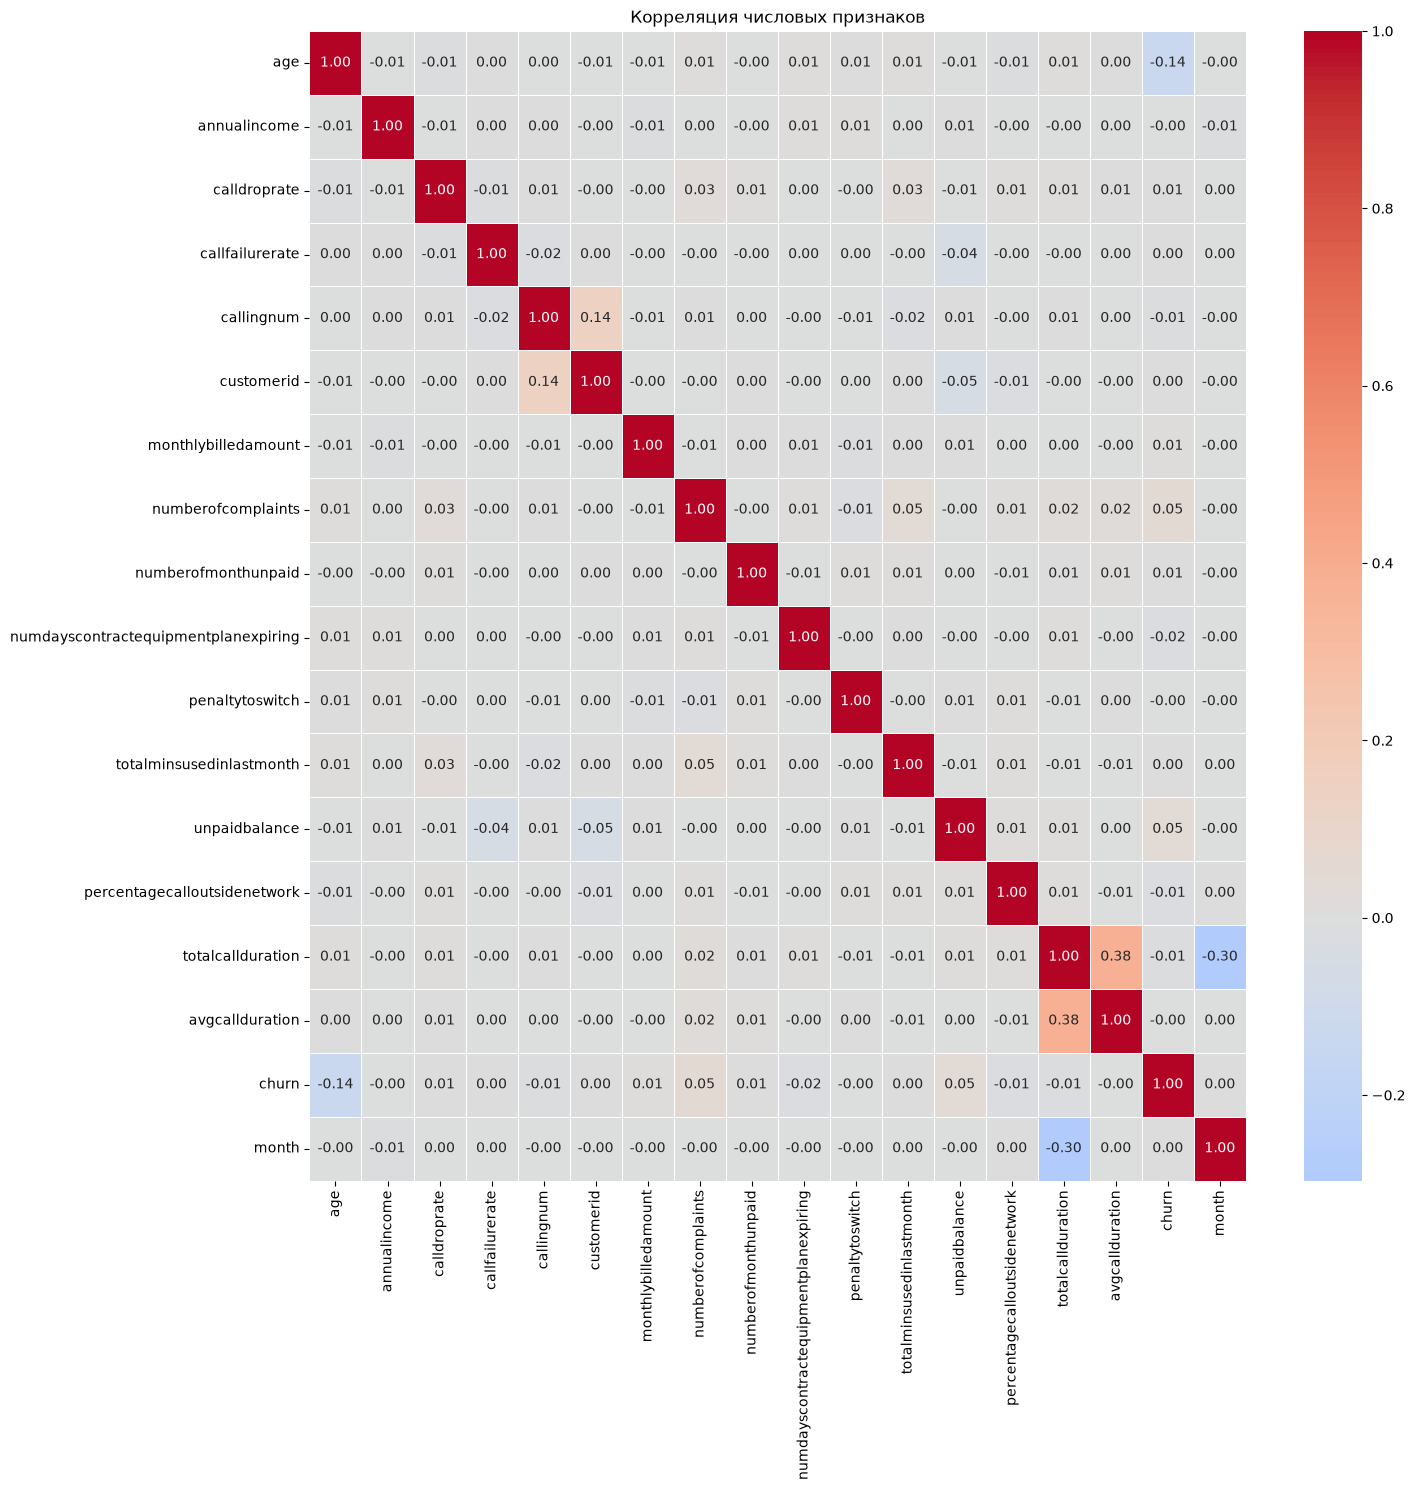

In [6]:
df=df.drop(columns='year')
# 7.2 Корреляционная матрица числовых
fig, ax = plt.subplots(figsize=(15, 15))
num_for_corr = df.select_dtypes(include="number").columns.tolist()
corr = df[num_for_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Корреляция числовых признаков", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\paink\AppData\Local\Temp\ipykernel_5456\2300791943.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


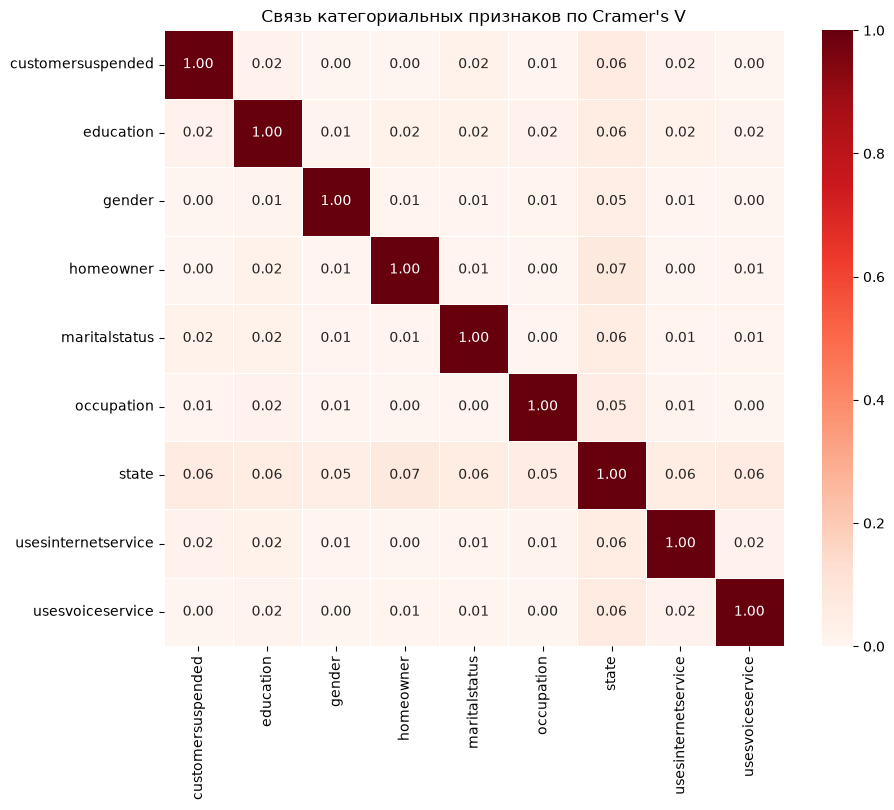

In [7]:
from scipy.stats import chi2_contingency
df=df.drop(columns='noadditionallines')
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)

    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1

    return np.sqrt(chi2 / (n * min_dim))

cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [col for col in cat_cols if col != "churn"]

cramers_matrix = pd.DataFrame(
    [[cramers_v(df[c1], df[c2]) for c2 in cat_cols] for c1 in cat_cols],
    index=cat_cols,
    columns=cat_cols
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_matrix,
    cmap="Reds",
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)
plt.title("Связь категориальных признаков по Cramer's V")
plt.show()

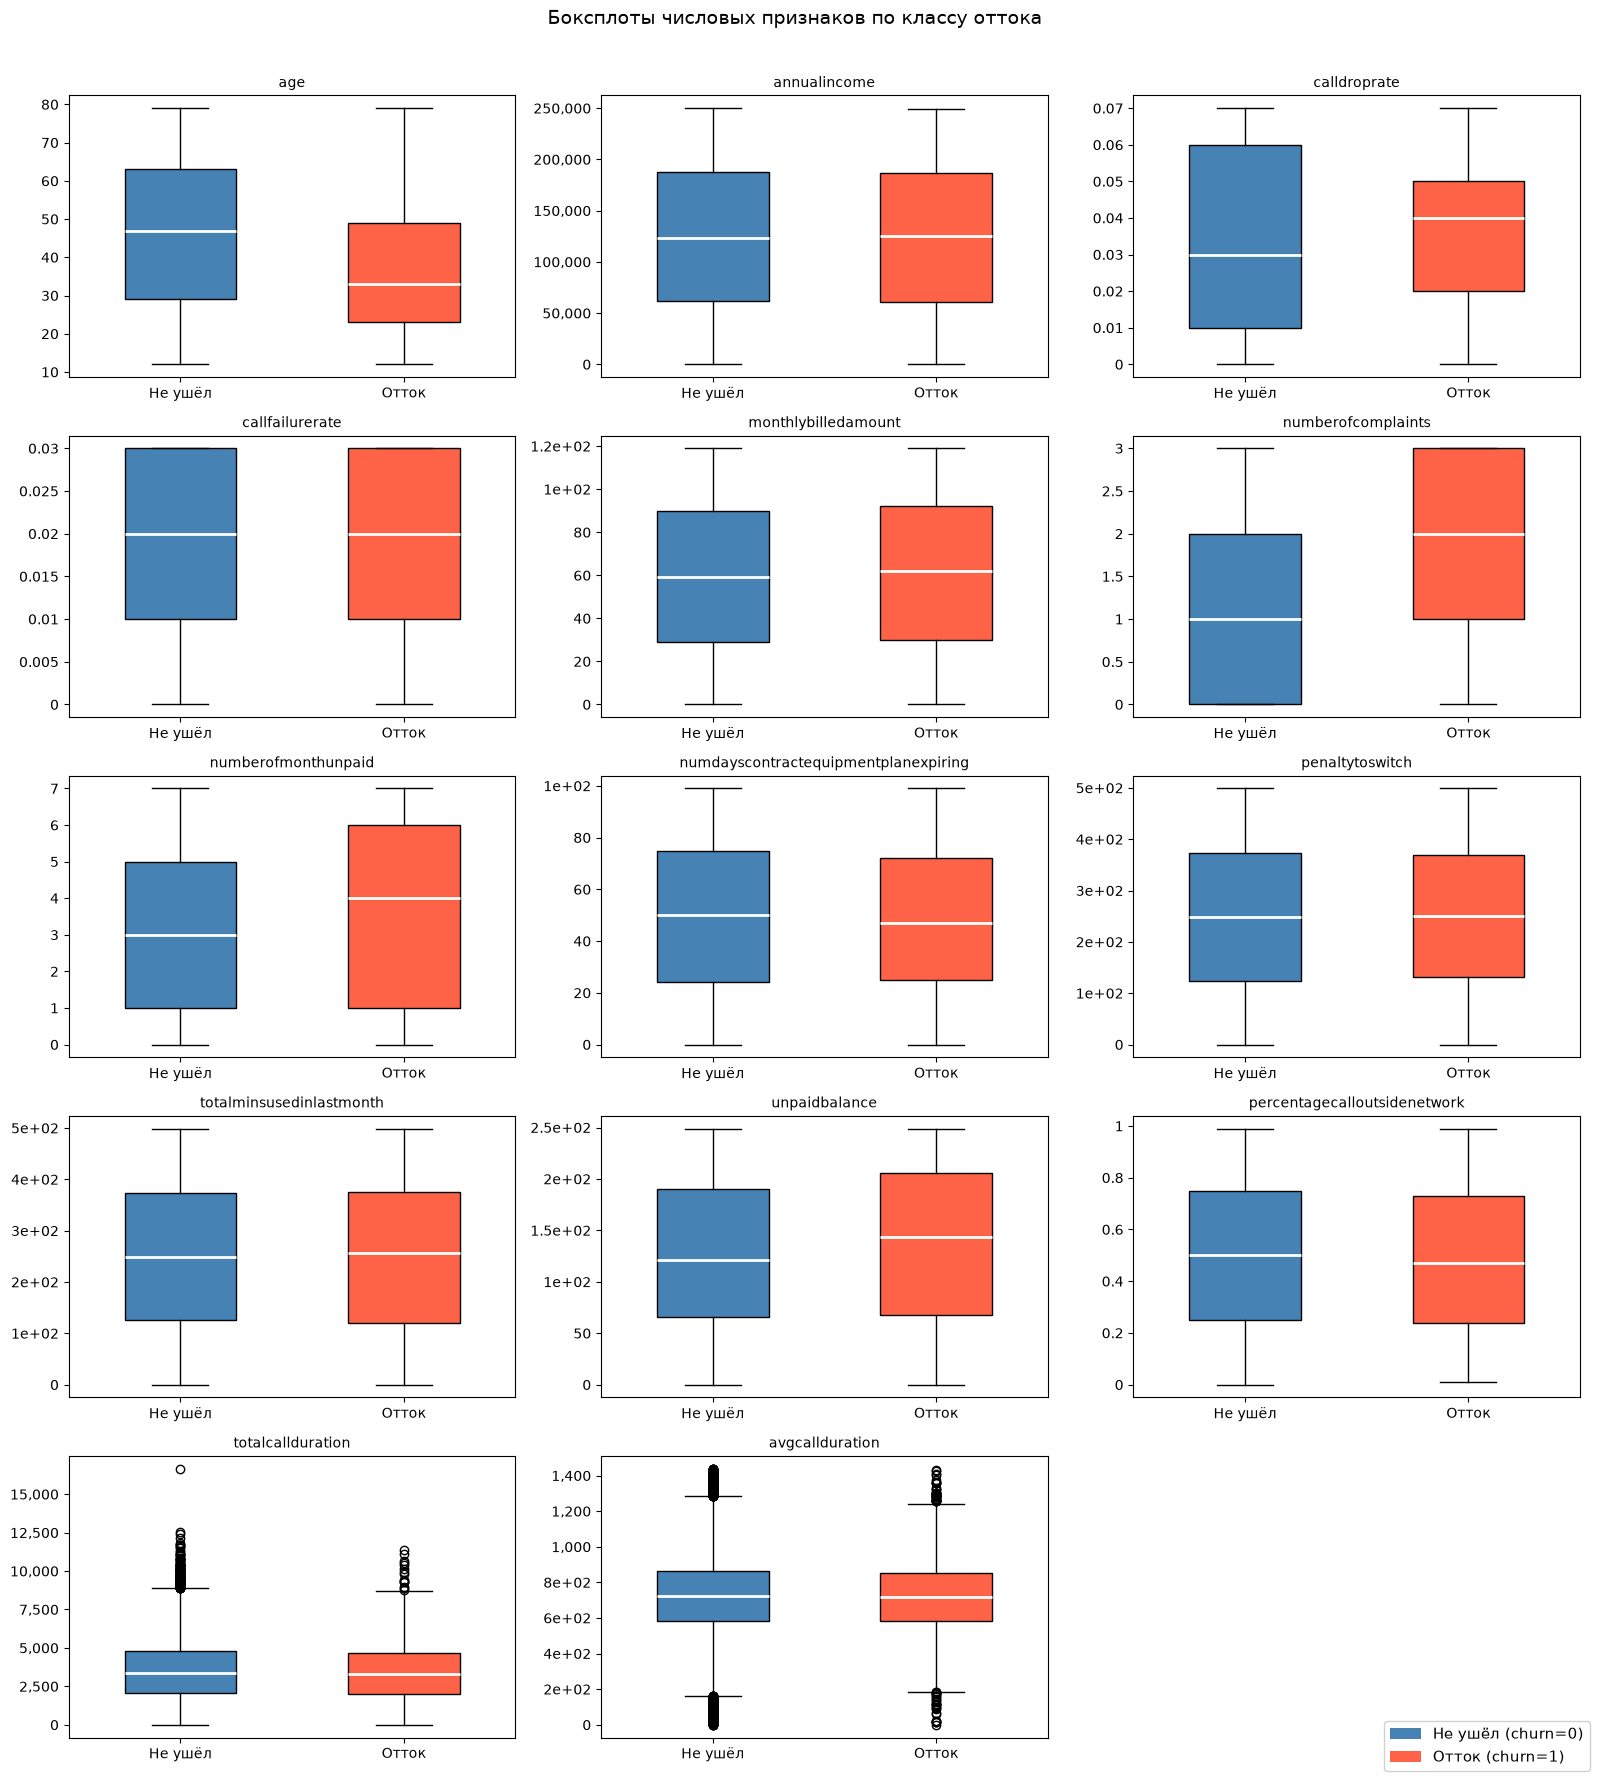

In [8]:
import matplotlib.ticker as mticker
DROP_COLS = ['customerid', 'callingnum', 'noadditionallines', 'year', 'month', 'churn']
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in DROP_COLS]

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # 5 строк

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = [
        df[df['churn'] == 0][col].dropna().values,
        df[df['churn'] == 1][col].dropna().values,
    ]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Не ушёл', 'Отток'])
    ax.set_title(col, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}' if abs(x) >= 1000 else f'{x:.2g}'
    ))

# Скрываем лишние оси (14 признаков → 15 ячеек, одна лишняя)
for ax in axes[len(num_cols):]:
    ax.set_visible(False)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Не ушёл (churn=0)'),
    Patch(facecolor='tomato',    label='Отток (churn=1)'),
]
fig.legend(handles=legend_elements, loc='lower right',
           fontsize=11, framealpha=0.9)

plt.suptitle('Боксплоты числовых признаков по классу оттока', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("data/telco-customer-churn.csv")

DROP_COLS = ['customerid', 'callingnum', 'noadditionallines',
             'year', 'month', 'churn',
             # категориальные
             'customersuspended', 'education', 'gender', 'homeowner',
             'maritalstatus', 'occupation', 'state',
             'usesinternetservice', 'usesvoiceservice']

X = df.drop(columns=DROP_COLS)
y = df['churn']

print(f'Признаки ({len(X.columns)}):')
print(list(X.columns))
print(f'\nПропуски:\n{X.isnull().sum()[X.isnull().sum() > 0]}')

Признаки (14):
['age', 'annualincome', 'calldroprate', 'callfailurerate', 'monthlybilledamount', 'numberofcomplaints', 'numberofmonthunpaid', 'numdayscontractequipmentplanexpiring', 'penaltytoswitch', 'totalminsusedinlastmonth', 'unpaidbalance', 'percentagecalloutsidenetwork', 'totalcallduration', 'avgcallduration']

Пропуски:
Series([], dtype: int64)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 16,374  |  Test: 4,094


In [12]:
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.5,
    depth=8,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

cb_model.fit(train_pool, eval_set=test_pool)

0:	test: 0.7319085	best: 0.7319085 (0)	total: 170ms	remaining: 2m 49s
100:	test: 0.9541959	best: 0.9559021 (91)	total: 1.66s	remaining: 14.8s
200:	test: 0.9597027	best: 0.9611487 (176)	total: 4.84s	remaining: 19.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.961148701
bestIteration = 176

Shrink model to first 177 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=8, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.5, random_seed=42, verbose=100)

In [13]:
y_pred  = cb_model.predict(test_pool)
y_proba = cb_model.predict_proba(test_pool)[:, 1]

print(f'ROC-AUC:           {roc_auc_score(y_test, y_proba):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Не ушёл', 'Отток']))

ROC-AUC:           0.9611
Average Precision: 0.9132

              precision    recall  f1-score   support

     Не ушёл       0.99      0.99      0.99      3721
       Отток       0.92      0.85      0.88       373

    accuracy                           0.98      4094
   macro avg       0.95      0.92      0.94      4094
weighted avg       0.98      0.98      0.98      4094



In [14]:
importances = pd.Series(
    cb_model.get_feature_importance(train_pool),
    index=X_train.columns
).sort_values(ascending=False)

print(importances.to_string())

age                                     16.145013
unpaidbalance                           11.973903
numberofcomplaints                       8.559168
percentagecalloutsidenetwork             8.320212
annualincome                             8.243425
totalminsusedinlastmonth                 8.012181
penaltytoswitch                          7.701947
numdayscontractequipmentplanexpiring     7.630966
monthlybilledamount                      7.126950
numberofmonthunpaid                      5.595847
callfailurerate                          4.831270
calldroprate                             4.000424
avgcallduration                          0.946200
totalcallduration                        0.912494


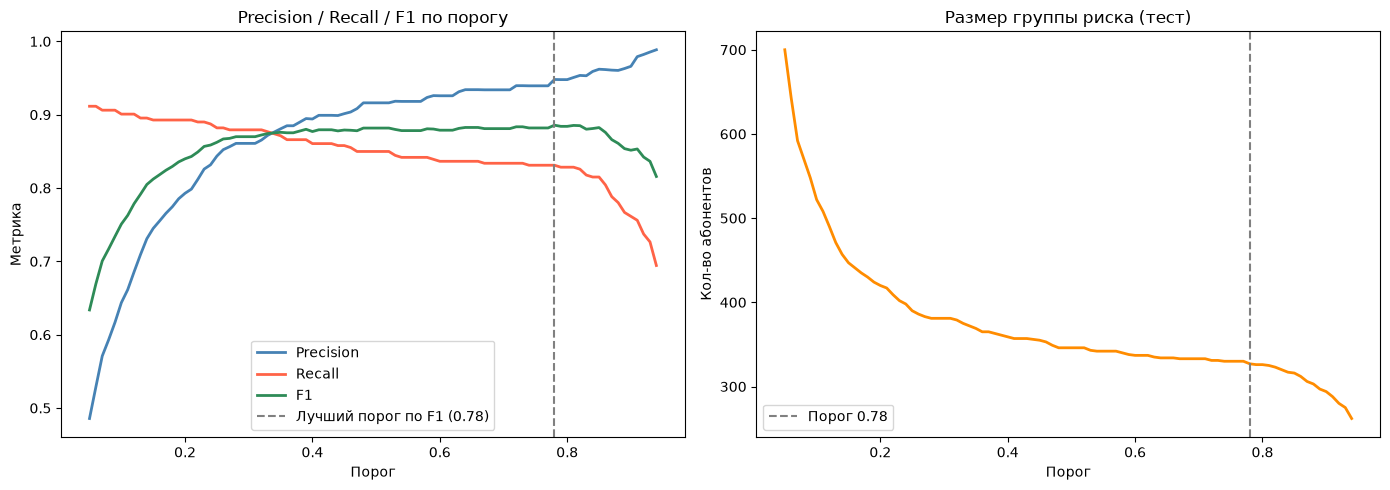

 Порог  Precision  Recall     F1   Группа риска   Пойманных оттоков
----------------------------------------------------------------------
  0.10      0.644   0.901  0.751            522                 336
  0.20      0.793   0.893  0.840            420                 333
  0.30      0.861   0.879  0.870            381                 328
  0.78      0.948   0.831  0.886            327                 310 ← best F1
  0.50      0.916   0.850  0.882            346                 317
  0.60      0.926   0.836  0.879            337                 312
  0.70      0.934   0.834  0.881            333                 311


In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(0.05, 0.95, 0.01)
precisions, recalls, f1_scores = [], [], []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tp = cm_t[1,1]; fp = cm_t[0,1]; fn = cm_t[1,0]
    p  = tp / (tp + fp + 1e-9)
    r  = tp / (tp + fn + 1e-9)
    f1 = 2*p*r / (p+r+1e-9)
    precisions.append(p); recalls.append(r); f1_scores.append(f1)

best_t = thresholds[np.argmax(f1_scores)]

# --- График ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: все три метрики
axes[0].plot(thresholds, precisions, label='Precision', color='steelblue', lw=2)
axes[0].plot(thresholds, recalls,    label='Recall',    color='tomato',    lw=2)
axes[0].plot(thresholds, f1_scores,  label='F1',        color='seagreen',  lw=2)
axes[0].axvline(best_t, linestyle='--', color='gray',
                label=f'Лучший порог по F1 ({best_t:.2f})')
axes[0].set_xlabel('Порог'); axes[0].set_ylabel('Метрика')
axes[0].set_title('Precision / Recall / F1 по порогу')
axes[0].legend()

# Правый: сколько абонентов попадает в группу риска
n_flagged = [(y_proba >= t).sum() for t in thresholds]
axes[1].plot(thresholds, n_flagged, color='darkorange', lw=2)
axes[1].axvline(best_t, linestyle='--', color='gray',
                label=f'Порог {best_t:.2f}')
axes[1].set_xlabel('Порог'); axes[1].set_ylabel('Кол-во абонентов')
axes[1].set_title('Размер группы риска (тест)')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Таблица по ключевым порогам ---
print(f'{"Порог":>6}  {"Precision":>9}  {"Recall":>6}  {"F1":>5}  {"Группа риска":>13}  {"Пойманных оттоков":>18}')
print('-' * 70)
for t in [0.10, 0.20, 0.30, best_t, 0.50, 0.60, 0.70]:
    y_pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tp = cm_t[1,1]; fp = cm_t[0,1]; fn = cm_t[1,0]
    p  = tp / (tp + fp + 1e-9)
    r  = tp / (tp + fn + 1e-9)
    f1 = 2*p*r / (p+r+1e-9)
    flagged = y_pred_t.sum()
    marker = ' ← best F1' if abs(t - best_t) < 0.005 else ''
    print(f'{t:>6.2f}  {p:>9.3f}  {r:>6.3f}  {f1:>5.3f}  {flagged:>13,}  {tp:>18}{marker}')

In [16]:
from sklearn.metrics import classification_report

y_pred_best = (y_proba >= best_t).astype(int)
print(f'Порог: {best_t:.2f}\n')
print(classification_report(y_test, y_pred_best, target_names=['Не ушёл', 'Отток']))
cm = confusion_matrix(y_test, y_pred)
print(cm)

Порог: 0.78

              precision    recall  f1-score   support

     Не ушёл       0.98      1.00      0.99      3721
       Отток       0.95      0.83      0.89       373

    accuracy                           0.98      4094
   macro avg       0.97      0.91      0.94      4094
weighted avg       0.98      0.98      0.98      4094

[[3692   29]
 [  56  317]]


        ОЦЕНКА БИЗНЕС-ЭФФЕКТА МОДЕЛИ

📋 ПАРАМЕТРЫ КАМПАНИИ
  Средний LTV абонента:             24,000 руб
  Размер группы риска:                 346 чел
  Из них реальных оттоков:             317 чел  (Precision 92%)
  Пропущено моделью:                    56 чел

💰 ФИНАНСОВЫЙ РЕЗУЛЬТАТ
  Удержано абонентов:                   79 чел  (25% от группы риска)
  Сохранённая выручка:           1,896,000 руб
  Затраты на обзвон:                34,600 руб
  Затраты на офферы:                39,500 руб
  Итого затрат:                     74,100 руб
  Чистая прибыль:                1,821,900 руб
  ROI кампании:                     2458.7%

⚠️  УПУЩЕННЫЕ ОТТОКИ (FN)
  Пропущено абонентов:                  56 чел
  Упущенная выручка:             1,344,000 руб

🔁 СРАВНЕНИЕ: МОДЕЛЬ VS ОБЗВОН ВСЕЙ БАЗЫ
  Обзвон всей базы — затраты:      409,400 руб
  Обзвон всей базы — прибыль:    1,822,600 руб
  Экономия за счёт модели:         335,300 руб



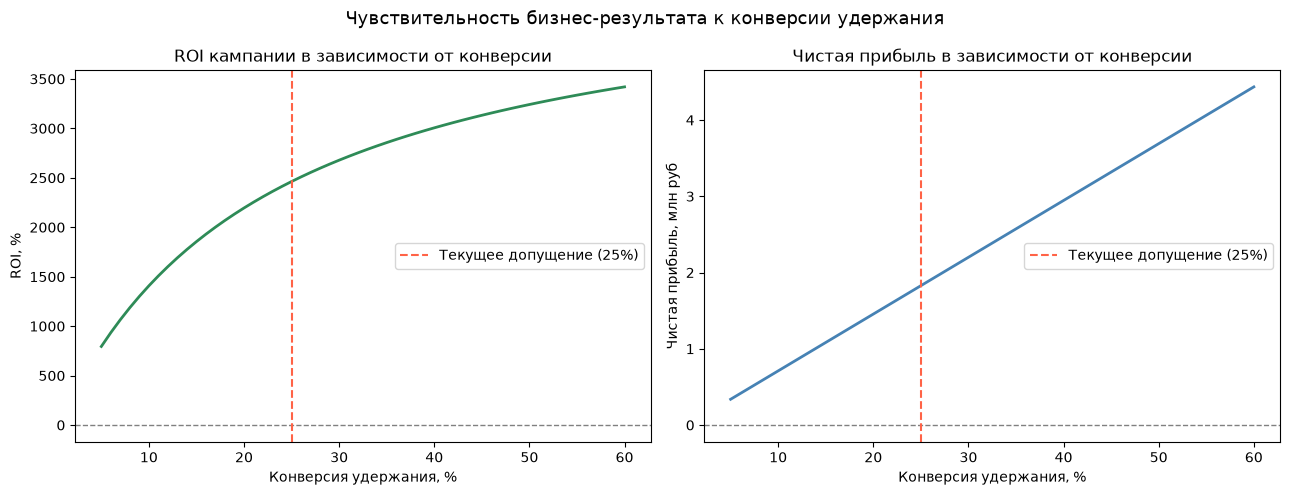

In [17]:

# БИЗНЕС-БЛОК: оценка применимости модели


# --- Параметры (меняй под реальный бизнес) ---
MONTHLY_REVENUE     = 1000    # средний ежемесячный доход с абонента, руб
LTV_MONTHS          = 24     # средний LTV в месяцах
RETENTION_COST      = 100    # стоимость одного контакта (звонок + оффер), руб
RETENTION_SUCCESS   = 0.25   # доля успешных удержаний из тех, кому позвонили
DISCOUNT_OFFER      = 500    # стоимость retention-оффера (скидка/бонус), руб

# --- Данные из модели ---
TP = 317   # верно предсказанных оттоков
FP = 29    # ложных тревог
FN = 56    # пропущенных оттоков

total_predicted_churn = TP + FP  # размер группы риска

# --- Расчёт ---
ltv = MONTHLY_REVENUE * LTV_MONTHS

# Выручка от удержанных
retained        = int(TP * RETENTION_SUCCESS)
revenue_saved   = retained * ltv

# Затраты на кампанию
cost_calls      = total_predicted_churn * RETENTION_COST
cost_offers     = retained * DISCOUNT_OFFER
total_cost      = cost_calls + cost_offers

# ROI
profit          = revenue_saved - total_cost
roi             = profit / total_cost * 100

# Упущенная выручка (пропущенные оттоки)
lost_revenue    = FN * ltv

print('=' * 55)
print('        ОЦЕНКА БИЗНЕС-ЭФФЕКТА МОДЕЛИ')
print('=' * 55)

print(f'\n📋 ПАРАМЕТРЫ КАМПАНИИ')
print(f'  Средний LTV абонента:         {ltv:>10,.0f} руб')
print(f'  Размер группы риска:          {total_predicted_churn:>10,} чел')
print(f'  Из них реальных оттоков:      {TP:>10,} чел  (Precision {TP/total_predicted_churn:.0%})')
print(f'  Пропущено моделью:            {FN:>10,} чел')

print(f'\n💰 ФИНАНСОВЫЙ РЕЗУЛЬТАТ')
print(f'  Удержано абонентов:           {retained:>10,} чел  ({RETENTION_SUCCESS:.0%} от группы риска)')
print(f'  Сохранённая выручка:          {revenue_saved:>10,.0f} руб')
print(f'  Затраты на обзвон:            {cost_calls:>10,.0f} руб')
print(f'  Затраты на офферы:            {cost_offers:>10,.0f} руб')
print(f'  Итого затрат:                 {total_cost:>10,.0f} руб')
print(f'  Чистая прибыль:               {profit:>10,.0f} руб')
print(f'  ROI кампании:                 {roi:>10.1f}%')

print(f'\n⚠️  УПУЩЕННЫЕ ОТТОКИ (FN)')
print(f'  Пропущено абонентов:          {FN:>10,} чел')
print(f'  Упущенная выручка:            {lost_revenue:>10,.0f} руб')

print(f'\n🔁 СРАВНЕНИЕ: МОДЕЛЬ VS ОБЗВОН ВСЕЙ БАЗЫ')
cost_all        = len(y_test) * RETENTION_COST
retained_all    = int(len(y_test[y_test==1]) * RETENTION_SUCCESS)
revenue_all     = retained_all * ltv
profit_all      = revenue_all - cost_all
print(f'  Обзвон всей базы — затраты:   {cost_all:>10,.0f} руб')
print(f'  Обзвон всей базы — прибыль:   {profit_all:>10,.0f} руб')
print(f'  Экономия за счёт модели:      {cost_all - total_cost:>10,.0f} руб')

print('\n' + '=' * 55)

# --- График: ROI при разных конверсиях удержания ---
import numpy as np
import matplotlib.pyplot as plt

retention_rates = np.arange(0.05, 0.61, 0.01)
rois, profits = [], []

for rate in retention_rates:
    ret   = TP * rate
    rev   = ret * ltv
    cost  = total_predicted_churn * RETENTION_COST + ret * DISCOUNT_OFFER
    rois.append((rev - cost) / cost * 100)
    profits.append(rev - cost)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(retention_rates * 100, rois, color='seagreen', lw=2)
axes[0].axhline(0, color='gray', linestyle='--', lw=1)
axes[0].axvline(RETENTION_SUCCESS * 100, color='tomato', linestyle='--',
                label=f'Текущее допущение ({RETENTION_SUCCESS:.0%})')
axes[0].set_xlabel('Конверсия удержания, %')
axes[0].set_ylabel('ROI, %')
axes[0].set_title('ROI кампании в зависимости от конверсии')
axes[0].legend()

axes[1].plot(retention_rates * 100, [p/1e6 for p in profits], color='steelblue', lw=2)
axes[1].axhline(0, color='gray', linestyle='--', lw=1)
axes[1].axvline(RETENTION_SUCCESS * 100, color='tomato', linestyle='--',
                label=f'Текущее допущение ({RETENTION_SUCCESS:.0%})')
axes[1].set_xlabel('Конверсия удержания, %')
axes[1].set_ylabel('Чистая прибыль, млн руб')
axes[1].set_title('Чистая прибыль в зависимости от конверсии')
axes[1].legend()

plt.suptitle('Чувствительность бизнес-результата к конверсии удержания', fontsize=13)
plt.tight_layout()
plt.show()